In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình hiển thị số thực (không hiện dạng 1.2e+09 khó đọc)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set(style="whitegrid")

# 1. Load dữ liệu
df = pd.read_csv('../data/processed/MultiUser_VitalSigns.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 2. Các chỉ số thống kê "Key Metrics" (Ghi nhớ các số này để báo cáo)
n_users = df['Id'].nunique()
n_rows = len(df)
start_date = df['Timestamp'].min()
end_date = df['Timestamp'].max()
duration = (end_date - start_date).days

print("=== BÁO CÁO TỔNG QUAN DATASET ===")
print(f"1. Tổng số dòng dữ liệu: {n_rows:,} records")
print(f"2. Số lượng người dùng (Subjects): {n_users}")
print(f"3. Thời gian thu thập: Từ {start_date} đến {end_date} (Tổng {duration} ngày)")
print(f"4. Tần suất lấy mẫu: 1 phút/lần (Minute-level resolution)")

# 3. Kiểm tra kiểu dữ liệu
print("\n=== CẤU TRÚC DỮ LIỆU ===")
df.info()

=== BÁO CÁO TỔNG QUAN DATASET ===
1. Tổng số dòng dữ liệu: 148,270 records
2. Số lượng người dùng (Subjects): 14
3. Thời gian thu thập: Từ 2016-03-29 00:00:00 đến 2016-04-12 11:03:00 (Tổng 14 ngày)
4. Tần suất lấy mẫu: 1 phút/lần (Minute-level resolution)

=== CẤU TRÚC DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148270 entries, 0 to 148269
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   Id          148270 non-null  int64         
 1   Timestamp   148270 non-null  datetime64[ns]
 2   Heart_Rate  148270 non-null  float64       
 3   Steps       148270 non-null  float64       
 4   Calories    148270 non-null  float64       
 5   Intensity   148270 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 6.8 MB


In [2]:
# 1. Kiểm tra Missing Values (NaN)
missing = df.isnull().sum()
print("\n=== CHECKING FOR MISSING VALUES ===")
print(missing)

# 2. Kiểm tra các giá trị bằng 0 (Zero Values)
# Steps = 0 là bình thường (đang ngồi/ngủ), nhưng cần biết tỷ lệ bao nhiêu
zeros_steps = (df['Steps'] == 0).mean() * 100
zeros_cal = (df['Calories'] == 0).mean() * 100

print("\n=== CHECKING RESTING STATE (ZERO VALUES) ===")
print(f"- Proportion of time without walking (Steps=0): {zeros_steps:.2f}%")
print(f"- Percentage of Calories = 0: {zeros_cal:.2f}%")

# 3. Kiểm tra Outliers sơ bộ (Nhịp tim quá cao hoặc quá thấp)
# Giả sử nhịp tim < 40 hoặc > 200 là bất thường
abnormal_hr = df[(df['Heart_Rate'] < 40) | (df['Heart_Rate'] > 200)]
print(f"\n- Number of abnormal heart rate data points (<40 or >200 BPM): {len(abnormal_hr)} rows")


=== CHECKING FOR MISSING VALUES ===
Id            0
Timestamp     0
Heart_Rate    0
Steps         0
Calories      0
Intensity     0
dtype: int64

=== CHECKING RESTING STATE (ZERO VALUES) ===
- Proportion of time without walking (Steps=0): 20.13%
- Percentage of Calories = 0: 0.51%

- Number of abnormal heart rate data points (<40 or >200 BPM): 2 rows


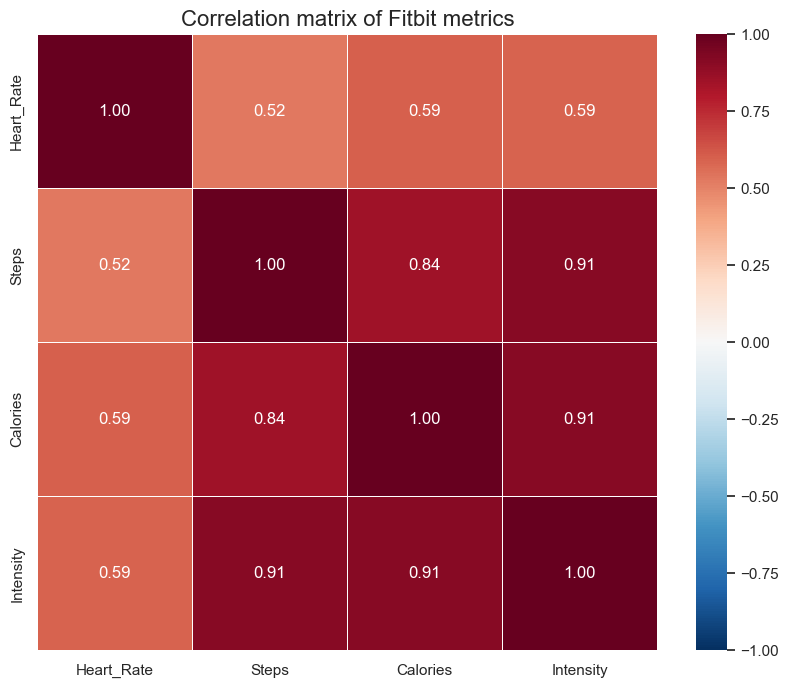

In [4]:
# Tính ma trận tương quan
corr_matrix = df[['Heart_Rate', 'Steps', 'Calories', 'Intensity']].corr()

plt.figure(figsize=(10, 8))
# Vẽ Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=.5, vmin=-1, vmax=1)

plt.title('Correlation matrix of Fitbit metrics', fontsize=16)
plt.show()

In [3]:
# Chọn 1 user để check gap
user_id = df['Id'].unique()[0]
user_df = df[df['Id'] == user_id].sort_values('Timestamp')

# Tính khoảng cách giữa 2 dòng liên tiếp
user_df['Time_Diff'] = user_df['Timestamp'].diff()

# Lọc những khoảng hở lớn hơn 2 phút (tức là bị mất dữ liệu > 1 phút)
gaps = user_df[user_df['Time_Diff'] > pd.Timedelta(minutes=2)]

print(f"=== PHÂN TÍCH KHOẢNG HỞ THỜI GIAN (USER {user_id}) ===")
print(f"Số lần bị ngắt quãng dữ liệu (> 2 phút): {len(gaps)} lần")
print("Top 5 khoảng ngắt quãng dài nhất:")
print(gaps['Time_Diff'].sort_values(ascending=False).head(5))

=== PHÂN TÍCH KHOẢNG HỞ THỜI GIAN (USER 8792009665) ===
Số lần bị ngắt quãng dữ liệu (> 2 phút): 15 lần
Top 5 khoảng ngắt quãng dài nhất:
685     0 days 21:21:00
10579   0 days 16:28:00
11486   0 days 12:31:00
8365    0 days 06:50:00
11548   0 days 05:44:00
Name: Time_Diff, dtype: timedelta64[ns]
